# FIFA World Cup 2026 - Objective 1 Data Science Solution

This notebook completes four distinct analytic tasks using the uploaded FBref FIFA World Cup 2026 CSV exports. Each task follows the assessment-required structure: analytic question formulation, data wrangling, data preparation and sampling, descriptive statistics, 95% confidence intervals, and an inferential t-test.

The notebook is intentionally written for assessment evidence: it shows the logic, code, validation checks, assumptions and limitations rather than only final graphs.


## Setup: libraries and helper functions

In [1]:

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path('.')
RAW = BASE / 'data' / 'raw'
PROC = BASE / 'data' / 'processed'
FIG = BASE / 'figures'
PROC.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
ALPHA = 0.05

def make_unique(columns):
    counts = {}
    out = []
    for col in columns:
        col = str(col).replace('▼', '').strip()
        if col in counts:
            counts[col] += 1
            out.append(f'{col}.{counts[col]}')
        else:
            counts[col] = 0
            out.append(col)
    return out

def read_fbref_csv(path):
    """Read FBref CSV exports with a grouped header row and a true column-name row."""
    df = pd.read_csv(path, header=1)
    df.columns = make_unique(df.columns)
    df = df.loc[:, ~df.columns.astype(str).str.match('^Unnamed')]
    for c in df.columns:
        if c not in ['Player', 'Pos', 'Squad', 'Club', 'Matches']:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df.dropna(how='all').reset_index(drop=True)

def ci_mean(x, confidence=0.95):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    tcrit = stats.t.ppf((1 + confidence) / 2, n - 1)
    return pd.Series({'n': n, 'mean': mean, 'sd': sd, 'se': se, 'lower': mean - tcrit*se, 'upper': mean + tcrit*se})

def welch_ci_diff(x1, x2, confidence=0.95):
    x1 = pd.Series(x1).dropna().astype(float)
    x2 = pd.Series(x2).dropna().astype(float)
    n1, n2 = len(x1), len(x2)
    m1, m2 = x1.mean(), x2.mean()
    v1, v2 = x1.var(ddof=1), x2.var(ddof=1)
    se = np.sqrt(v1/n1 + v2/n2)
    df = (v1/n1 + v2/n2)**2 / (((v1/n1)**2)/(n1-1) + ((v2/n2)**2)/(n2-1))
    tcrit = stats.t.ppf((1 + confidence) / 2, df)
    diff = m1 - m2
    return pd.Series({'difference': diff, 'lower': diff - tcrit*se, 'upper': diff + tcrit*se, 'df': df, 'se': se})

def descriptive_table(sample, group_col, value_col):
    return sample.groupby(group_col)[value_col].agg(
        count='count', mean='mean', median='median', std='std', min='min',
        q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75), max='max'
    ).round(3)

def assumption_checks(sample, group_col, value_col, group_order):
    g1 = sample.loc[sample[group_col] == group_order[0], value_col].dropna().astype(float)
    g2 = sample.loc[sample[group_col] == group_order[1], value_col].dropna().astype(float)
    shapiro_1 = stats.shapiro(g1)
    shapiro_2 = stats.shapiro(g2)
    levene = stats.levene(g1, g2)
    q1_1, q3_1 = g1.quantile([0.25, 0.75]); iqr1 = q3_1 - q1_1
    q1_2, q3_2 = g2.quantile([0.25, 0.75]); iqr2 = q3_2 - q1_2
    outliers_1 = ((g1 < q1_1 - 1.5*iqr1) | (g1 > q3_1 + 1.5*iqr1)).sum()
    outliers_2 = ((g2 < q1_2 - 1.5*iqr2) | (g2 > q3_2 + 1.5*iqr2)).sum()
    return pd.Series({
        f'Shapiro p ({group_order[0]})': shapiro_1.pvalue,
        f'Shapiro p ({group_order[1]})': shapiro_2.pvalue,
        'Levene p': levene.pvalue,
        f'IQR outliers ({group_order[0]})': int(outliers_1),
        f'IQR outliers ({group_order[1]})': int(outliers_2),
    })

def run_inference(sample, group_col, value_col, group_order):
    g1 = sample.loc[sample[group_col] == group_order[0], value_col].dropna().astype(float)
    g2 = sample.loc[sample[group_col] == group_order[1], value_col].dropna().astype(float)
    t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    return {
        'descriptive': descriptive_table(sample, group_col, value_col),
        'ci_group1': ci_mean(g1).round(3),
        'ci_group2': ci_mean(g2).round(3),
        'ci_difference': welch_ci_diff(g1, g2).round(3),
        'ttest': pd.Series({'t statistic': t_stat, 'p-value': p_val}).round(5),
        'assumptions': assumption_checks(sample, group_col, value_col, group_order).round(5),
        'sensitivity': pd.Series({'Mann-Whitney U': u_stat, 'Mann-Whitney p-value': u_p}).round(5)
    }

def stratified_sample(df, group_col, n_per_group, random_state=RANDOM_STATE):
    return pd.concat([
        sub.sample(n=min(n_per_group, len(sub)), random_state=random_state)
        for _, sub in df.groupby(group_col, sort=False)
    ], ignore_index=True)

def save_boxplot(sample, group_col, value_col, title, ylabel, order, out_path):
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    data = [sample.loc[sample[group_col] == g, value_col].dropna() for g in order]
    ax.boxplot(data, tick_labels=order, showmeans=True)
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()


## Load raw FBref CSV exports

In [2]:

squad_standard = read_fbref_csv(RAW/'squad_standard.csv')
squad_shooting = read_fbref_csv(RAW/'squad_shooting.csv')
squad_goalkeeping = read_fbref_csv(RAW/'squad_goalkeeping.csv')
player_standard = read_fbref_csv(RAW/'player_standard.csv')
player_shooting = read_fbref_csv(RAW/'player_shooting.csv')
player_misc = read_fbref_csv(RAW/'player_miscellaneous.csv')

raw_shapes = pd.DataFrame({
    'Dataset': ['squad_standard', 'squad_shooting', 'squad_goalkeeping', 'player_standard', 'player_shooting', 'player_miscellaneous'],
    'Rows': [len(squad_standard), len(squad_shooting), len(squad_goalkeeping), len(player_standard), len(player_shooting), len(player_misc)],
    'Columns': [squad_standard.shape[1], squad_shooting.shape[1], squad_goalkeeping.shape[1], player_standard.shape[1], player_shooting.shape[1], player_misc.shape[1]]
})
raw_shapes


,Dataset,Rows,Columns
0,squad_standard,48,21
1,squad_shooting,48,13
2,squad_goalkeeping,48,21
3,player_standard,1039,26
4,player_shooting,1039,19
5,player_miscellaneous,1039,21


## Data acquisition and validation checks

In [3]:

validation_checks = {
    'squad team count consistent': len(squad_standard) == len(squad_shooting) == len(squad_goalkeeping),
    'player count consistent': len(player_standard) == len(player_shooting) == len(player_misc),
    'squad shooting SoT <= Sh': bool((squad_shooting['SoT'] <= squad_shooting['Sh']).all()),
    'player shooting SoT <= Sh': bool((player_shooting['SoT'] <= player_shooting['Sh']).all()),
    'squad Save% in 0-100': bool(squad_goalkeeping['Save%'].dropna().between(0, 100).all()),
    'squad Saves <= SoTA': bool((squad_goalkeeping['Saves'] <= squad_goalkeeping['SoTA']).all())
}
pd.Series(validation_checks)


squad team count consistent    True
player count consistent        True
squad shooting SoT <= Sh       True
player shooting SoT <= Sh      True
squad Save% in 0-100           True
squad Saves <= SoTA            True
dtype: bool

## Analytic Task 4 - Team goalkeeping
Question: Do knockout-stage teams have a higher goalkeeper save percentage than group-stage exit teams?

**H0:** The mean save percentage is equal for knockout-stage and group-stage exit teams.

**H1:** The two means are different.

Descriptive statistics


,count,mean,median,std,min,q1,q3,max
Progression,,,,,,,,
Group-stage exit,16,58.531,58.95,13.907,33.3,50.000,67.275,83.3
Knockout stage,16,68.950,70.70,11.887,47.1,58.675,76.375,90.9


95% CI - Knockout stage


n        16.000
mean     68.950
sd       11.887
se        2.972
lower    62.616
upper    75.284
dtype: float64

95% CI - Group-stage exit


...

t statistic    2.27792
p-value        0.03021
dtype: float64

Assumption checks


Shapiro p (Knockout stage)         0.69528
Shapiro p (Group-stage exit)       0.95070
Levene p                           0.49499
IQR outliers (Knockout stage)      0.00000
IQR outliers (Group-stage exit)    0.00000
dtype: float64

Sensitivity check


Mann-Whitney U          182.50000
Mann-Whitney p-value      0.04174
dtype: float64

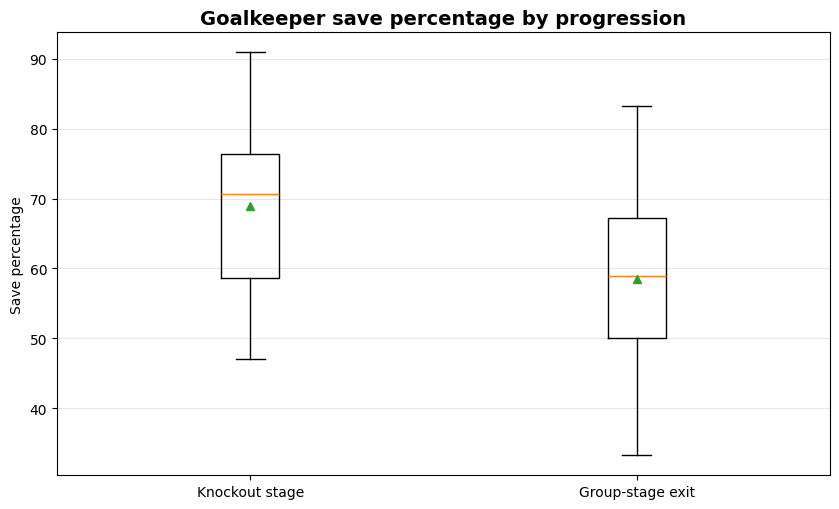

In [7]:

# Analytic question: Do knockout-stage teams have a higher goalkeeper save percentage than group-stage exit teams?
team_goalkeeping = squad_goalkeeping[['Squad', 'MP', '90s', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'CS%']].merge(
    squad_standard[['Squad', 'MP']], on='Squad', suffixes=('', '_std'), validate='one_to_one'
)
team_goalkeeping['Progression'] = np.where(team_goalkeeping['MP_std'] > 3, 'Knockout stage', 'Group-stage exit')
team_goalkeeping['SoTA_per90'] = team_goalkeeping['SoTA'] / team_goalkeeping['90s']

# Population: all World Cup squads. Sampling frame: squads with valid goalkeeping data.
# Sampling method: stratified random sampling by progression. All 16 group exits are retained and 16 knockout teams are sampled.
task4_sample = stratified_sample(team_goalkeeping, 'Progression', 16)
task4_sample.to_csv(PROC/'task4_team_goalkeeping_save_percentage.csv', index=False)

result_task4 = run_inference(task4_sample, 'Progression', 'Save%', ['Knockout stage', 'Group-stage exit'])
print('Descriptive statistics')
display(result_task4['descriptive'])
print('95% CI - Knockout stage')
display(result_task4['ci_group1'])
print('95% CI - Group-stage exit')
display(result_task4['ci_group2'])
print('95% CI - mean difference (Knockout - Exit)')
display(result_task4['ci_difference'])
print('Welch two-sample t-test')
display(result_task4['ttest'])
print('Assumption checks')
display(result_task4['assumptions'])
print('Sensitivity check')
display(result_task4['sensitivity'])
save_boxplot(task4_sample, 'Progression', 'Save%', 'Goalkeeper save percentage by progression', 'Save percentage', ['Knockout stage','Group-stage exit'], FIG/'task4_boxplot.png')


## Summary of inferential findings

In [8]:

summary_rows = []
for label, res, g1, g2 in [
    ('Task 1: On-target threat per possession', result_task1, 'Knockout stage', 'Group-stage exit'),
    ('Task 2: Shooting accuracy', result_task2, 'FW', 'MF'),
    ('Task 3: Fouls per 90', result_task3, 'MF', 'DF'),
    ('Task 4: Save percentage', result_task4, 'Knockout stage', 'Group-stage exit'),
]:
    summary_rows.append({
        'Task': label,
        'Group 1': g1,
        'Group 2': g2,
        'Mean difference': res['ci_difference']['difference'],
        '95% CI lower': res['ci_difference']['lower'],
        '95% CI upper': res['ci_difference']['upper'],
        'Welch p-value': res['ttest']['p-value'],
        'Decision at alpha=.05': 'Reject H0' if res['ttest']['p-value'] < ALPHA else 'Fail to reject H0'
    })
summary_table = pd.DataFrame(summary_rows)
summary_table.round(4)


,Task,Group 1,Group 2,Mean difference,95% CI lower,95% CI upper,Welch p-value,Decision at alpha=.05
0,Task 1: On-target threat per possession,Knockout stage,Group-stage exit,2.497,0.816,4.178,0.0050,Reject H0
1,Task 2: Shooting accuracy,FW,MF,12.853,4.551,21.155,0.0028,Reject H0
2,Task 3: Fouls per 90,MF,DF,0.299,0.110,0.487,0.0020,Reject H0
3,Task 4: Save percentage,Knockout stage,Group-stage exit,10.419,1.068,19.769,0.0302,Reject H0


## Overall conclusion

The four analyses give a coherent football story. Teams that progressed beyond the group stage tended to create more on-target shooting threat relative to possession and recorded better goalkeeping save percentages. At player level, forwards were more accurate shooters than midfielders after filtering for meaningful minutes and shooting involvement. Midfielders committed more fouls per 90 minutes than defenders in the sampled data, which may reflect their role in pressing, transitions and central duels.

These results should not be interpreted as causal. They are observational comparisons from one tournament. The t-tests compare group means, and the results are sensitive to eligibility rules and the limited number of teams in a World Cup. The notebook therefore reports assumption checks and a Mann-Whitney U sensitivity check alongside the required Welch t-tests.
